1. INGESTING RAW DATA
Total records ingested: 9,994

2. AUTOMATED DATA CLEANING & PREPROCESSING
Duplicate records removed: 0
Text fields normalized (trimmed whitespace & title-cased).
Date columns successfully formatted to datetime.
Null / Missing values handled: 0

3. EXECUTING SUMMARY KPI AGGREGATIONS
                Executive Metric         Value
          Total Processed Orders         5,009
               Total Revenue ($) $2,297,200.86
                Total Profit ($)   $286,397.02
       Overall Profit Margin (%)        12.47%
Average Shipping Duration (Days)      4.0 days
              Duplicates Removed             0

Automated Excel report generated: 'Automated_Executive_Report.xlsx'

4. GENERATING VISUAL REPORT


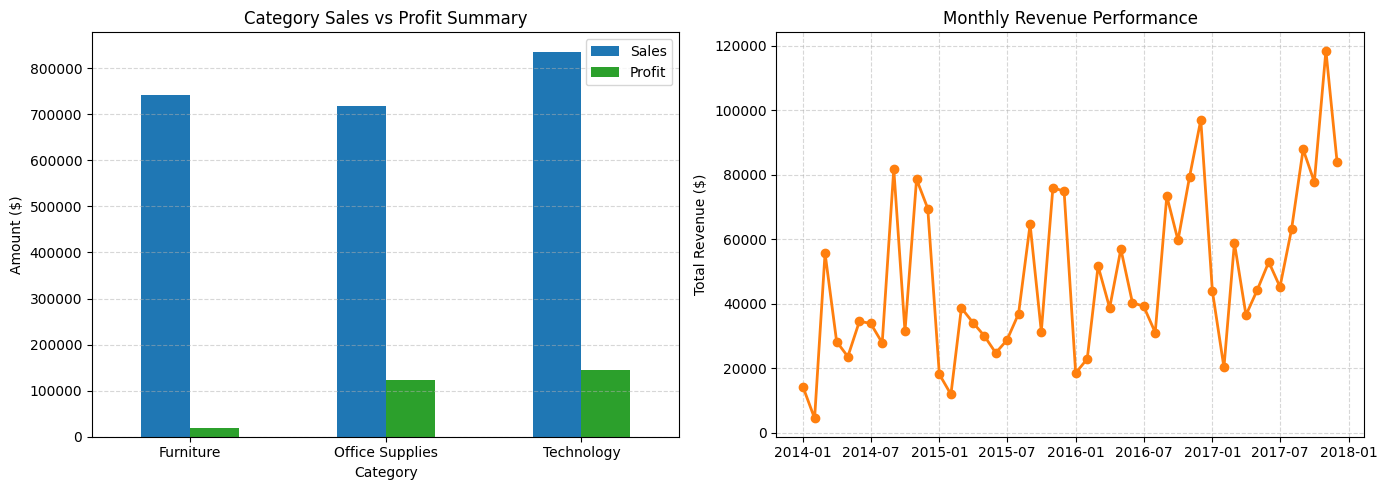

Visual report saved as 'automated_reporting_summary.png'


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def run_automated_pipeline(file_path):
    print("=" * 50)
    print("1. INGESTING RAW DATA")
    print("=" * 50)
    raw_df = pd.read_csv(file_path, encoding='latin1')
    initial_rows = len(raw_df)
    print(f"Total records ingested: {initial_rows:,}")

    print("\n" + "=" * 50)
    print("2. AUTOMATED DATA CLEANING & PREPROCESSING")
    print("=" * 50)
    # Check and remove duplicates
    cleaned_df = raw_df.drop_duplicates()
    duplicates_removed = initial_rows - len(cleaned_df)
    print(f"Duplicate records removed: {duplicates_removed}")

    # Standardize string columns (strip trailing spaces, title casing)
    for col in ['Customer Name', 'City', 'State', 'Region', 'Category', 'Sub-Category']:
        if col in cleaned_df.columns:
            cleaned_df[col] = cleaned_df[col].astype(str).str.strip().str.title()
    print("Text fields normalized (trimmed whitespace & title-cased).")

    # Standardize Datetime objects
    cleaned_df['Order Date'] = pd.to_datetime(cleaned_df['Order Date'])
    cleaned_df['Ship Date'] = pd.to_datetime(cleaned_df['Ship Date'])
    print("Date columns successfully formatted to datetime.")

    # Handle missing / null records
    missing_count = cleaned_df.isnull().sum().sum()
    if missing_count > 0:
        cleaned_df = cleaned_df.fillna({'Postal Code': 0})
    print(f"Null / Missing values handled: {missing_count}")

    # Engineered metrics for executive reporting
    cleaned_df['YearMonth'] = cleaned_df['Order Date'].dt.to_period('M')
    cleaned_df['Shipping Days'] = (cleaned_df['Ship Date'] - cleaned_df['Order Date']).dt.days

    print("\n" + "=" * 50)
    print("3. EXECUTING SUMMARY KPI AGGREGATIONS")
    print("=" * 50)
    total_revenue = cleaned_df['Sales'].sum()
    total_profit = cleaned_df['Profit'].sum()
    total_orders = cleaned_df['Order ID'].nunique()
    profit_margin = (total_profit / total_revenue) * 100
    avg_shipping_time = cleaned_df['Shipping Days'].mean()

    summary_kpis = pd.DataFrame({
        "Executive Metric": [
            "Total Processed Orders",
            "Total Revenue ($)",
            "Total Profit ($)",
            "Overall Profit Margin (%)",
            "Average Shipping Duration (Days)",
            "Duplicates Removed"
        ],
        "Value": [
            f"{total_orders:,}",
            f"${total_revenue:,.2f}",
            f"${total_profit:,.2f}",
            f"{profit_margin:.2f}%",
            f"{avg_shipping_time:.1f} days",
            f"{duplicates_removed}"
        ]
    })
    print(summary_kpis.to_string(index=False))

    # Aggregations for visual reporting
    category_summary = cleaned_df.groupby('Category').agg({
        'Sales': 'sum',
        'Profit': 'sum',
        'Quantity': 'sum'
    }).reset_index()

    # Save cleaned dataset and reports to a multi-sheet Excel file
    excel_report_name = 'Automated_Executive_Report.xlsx'
    with pd.ExcelWriter(excel_report_name) as writer:
        summary_kpis.to_excel(writer, sheet_name='Executive KPIs', index=False)
        category_summary.to_excel(writer, sheet_name='Category Summary', index=False)
        cleaned_df.to_excel(writer, sheet_name='Cleaned Data', index=False)
    print(f"\nAutomated Excel report generated: '{excel_report_name}'")

    print("\n" + "=" * 50)
    print("4. GENERATING VISUAL REPORT")
    print("=" * 50)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Bar plot for sales and profit by category
    category_summary.plot(x='Category', y=['Sales', 'Profit'], kind='bar', ax=axes[0], color=['#1f77b4', '#2ca02c'], rot=0)
    axes[0].set_title('Category Sales vs Profit Summary', fontsize=12)
    axes[0].set_ylabel('Amount ($)')
    axes[0].grid(axis='y', linestyle='--', alpha=0.5)

    # Monthly revenue trend
    monthly_sales = cleaned_df.groupby(cleaned_df['Order Date'].dt.to_period('M'))['Sales'].sum()
    monthly_sales.index = monthly_sales.index.to_timestamp()
    axes[1].plot(monthly_sales.index, monthly_sales.values, marker='o', color='#ff7f0e', linewidth=2)
    axes[1].set_title('Monthly Revenue Performance', fontsize=12)
    axes[1].set_ylabel('Total Revenue ($)')
    axes[1].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    chart_name = 'automated_reporting_summary.png'
    plt.savefig(chart_name)
    plt.show()
    print(f"Visual report saved as '{chart_name}'")

# Execute automated pipeline
run_automated_pipeline('Sample - Superstore.csv')